# Partial control sets and infinite-horizon energy

The control set $B$ decides which nodes receive input: control node $i$ has weight $B_{ii}$ on the diagonal. The
other tutorials give every node equal control ($B = I$, a uniform full control set). This one restricts control to
some nodes, a *partial* control set, and looks at what that does to control energy, over a finite time horizon with
{func}`~nctpy.energies.get_control_inputs` and over an infinite one with the controllability Gramian, as in Kim et al.
(*Nat Commun* 2025, Fig. 3).

It uses the synthetic connectome of {doc}`protocol_workflow`, and matplotlib: `pip install "nctpy[plot]"`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance

from nctpy.energies import average_energy_infinite, get_control_inputs, integrate_u, minimum_energy_infinite
from nctpy.plotting import set_plotting_params
from nctpy.utils import (
    convert_states_str2int, mask_control_set, matrix_normalization, normalize_state, random_control_set,
)

set_plotting_params()

In [2]:
def make_connectome(n_nodes=100, n_systems=7, length=0.5, seed=0):
    rng = np.random.default_rng(seed)
    # node coordinates on a unit sphere, ordered by longitude so that systems are contiguous
    xyz = rng.normal(size=(n_nodes, 3))
    xyz /= np.linalg.norm(xyz, axis=1, keepdims=True)
    xyz = xyz[np.argsort(np.arctan2(xyz[:, 1], xyz[:, 0]))]
    names = [chr(ord("A") + i) for i in range(n_systems)]
    labels = [names[i] for i, nodes in enumerate(np.array_split(np.arange(n_nodes), n_systems)) for _ in nodes]
    # connection probability and weight fall off with distance; within-system pairs are twice as likely
    dist = distance.squareform(distance.pdist(xyz, "euclidean"))
    decay = np.exp(-dist / length)
    p = np.where(np.equal.outer(labels, labels), np.minimum(1, 2 * decay), decay)
    edges = np.triu(rng.random((n_nodes, n_nodes)) < p, k=1)
    weights = rng.lognormal(0, 1, size=(n_nodes, n_nodes)) * decay
    A = np.where(edges, weights, 0)
    return A + A.T, dist, labels


adjacency, _, system_labels = make_connectome()
n_nodes = adjacency.shape[0]
system = "continuous"
adjacency_norm = matrix_normalization(A=adjacency, system=system, c=1)

states, state_labels = convert_states_str2int(system_labels)
initial_state = normalize_state(states == state_labels.index("A"))
target_state = normalize_state(states == state_labels.index("D"))

## Control sets from a mask

{func}`~nctpy.utils.mask_control_set` builds $B$ from a mask of control nodes, for example the nodes of one
system. Here the transition from system A to system D is driven by every node, by the nodes of A only, of D only,
and of A and D together:

In [3]:
control_sets = {
    "all nodes": np.eye(n_nodes),
    "A": mask_control_set(states == state_labels.index("A")),
    "D": mask_control_set(states == state_labels.index("D")),
    "A and D": mask_control_set(np.isin(states, [state_labels.index("A"), state_labels.index("D")])),
}


def transition(control_set, T=1):
    _, control_signals, numerical_error = get_control_inputs(
        A_norm=adjacency_norm, T=T, B=control_set, x0=initial_state, xf=target_state,
        system=system, rho=1, S=np.eye(n_nodes),
    )
    return np.sum(integrate_u(control_signals)), numerical_error


for name, control_set in control_sets.items():
    energy, numerical_error = transition(control_set)
    print("{:>10}: energy = {:9.3g}; errors = {:.1E}, {:.1E}".format(name, energy, *numerical_error))

 all nodes: energy =  2.55e+03; errors = 9.4E-16, 5.4E-14
         A: energy =  2.19e+23; errors = 3.7E+02, 4.5E+04
         D: energy =  1.94e+22; errors = 8.7E+01, 6.3E+03
   A and D: energy =  2.96e+04; errors = 2.4E-12, 1.9E-10


Controlling only A, or only D, the errors are far above $10^{-8}$: the transition did not complete, and its
energy means nothing. nctpy still returns the result rather than raising, so that you can inspect it; always check
the errors (the protocol paper's Table 1 lists what to try when they are large). Controlling A and D together, the
transition completes.

`mask_control_set` (like {func}`~nctpy.utils.random_control_set`) takes a `baseline`: a control weight for every
node outside the mask. A small baseline gives every node a little control, which can make an incomplete transition
complete (here, from a baseline of 1e-3). It changes the control set, though, and the energy then depends strongly on the value chosen, so compare
energies only between control sets with the same baseline:

In [4]:
for baseline in (1e-5, 1e-3, 1e-2):
    control_set = mask_control_set(states == state_labels.index("A"), baseline=baseline)
    energy, numerical_error = transition(control_set)
    print("A, baseline {:.0e}: energy = {:9.3g}; errors = {:.1E}, {:.1E}".format(baseline, energy, *numerical_error))

A, baseline 1e-05: energy =  1.31e+13; errors = 1.4E-08, 2.1E-06
A, baseline 1e-03: energy =  1.77e+09; errors = 5.7E-12, 2.1E-10
A, baseline 1e-02: energy =  1.83e+07; errors = 2.0E-14, 3.3E-12


## Random control sets

{func}`~nctpy.utils.random_control_set` draws a given number of control nodes at random, from a seed. Kim et al.
(2025) used 20 random sets of each size (seeds 0 to 19); the same seeds give the same control nodes here.

In [5]:
control_set = random_control_set(n_nodes, 10, seed=0)
print(np.flatnonzero(np.diag(control_set)))  # the 10 control nodes

[ 2 16 26 54 55 73 75 86 93 95]


## Energy over an infinite time horizon

Over an infinite time horizon, control energy follows from the infinite-horizon controllability Gramian $W_c$ of
the pair $(A_\text{norm}, B)$, the solution of a Lyapunov equation, with no integration over time. Two measures are
available:

- {func}`~nctpy.energies.average_energy_infinite`: $\operatorname{tr}(W_c^{-1})$, proportional to the average
  minimum energy over all target states of unit size. It describes the control set, not a particular transition.
  This is the energy shown in Kim et al.'s Fig. 3C, there multiplied by the time step, 0.001.
- {func}`~nctpy.energies.minimum_energy_infinite`: $x_f^\top W_c^{-1} x_f$, the minimum energy to reach a target
  state $x_f$. Over an infinite horizon the initial state has decayed away, so only the target matters.

Both need a stable system, which normalisation provides. Here, average energy for 20 random control sets of each
size:

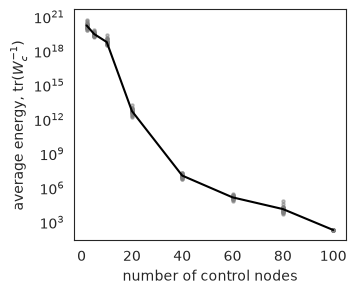

In [6]:
sizes = [100, 80, 60, 40, 20, 10, 5, 2]
seeds = np.arange(20)
average_energy = np.array([
    [average_energy_infinite(adjacency_norm, random_control_set(n_nodes, size, seed=seed), system=system)
     for seed in seeds]
    for size in sizes
])

f, ax = plt.subplots(1, 1, figsize=(3.5, 3))
for size, energies in zip(sizes, average_energy):
    ax.scatter(np.full(len(energies), size), energies, s=5, color="gray", alpha=0.5)
ax.plot(sizes, np.median(average_energy, axis=1), color="black")
ax.set_yscale("log")
ax.set_xlabel("number of control nodes")
ax.set_ylabel("average energy, tr($W_c^{-1}$)")
plt.show()

Energy rises steeply as the control set shrinks: with fewer nodes receiving input, the remaining ones must
work much harder. How far these values can be trusted at the smallest sizes is the subject of the next section.

## Minimum energy to a target, and its accuracy

With few control nodes, $W_c$ is close to singular, and inverting it loses accuracy.
`minimum_energy_infinite` returns, besides the energy at each node, `xf_reached`: the target as reconstructed
through the inverse Gramian. Its distance from $x_f$ shows how far the energy can be trusted.

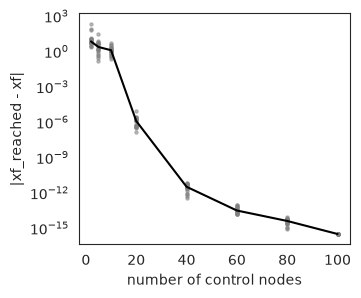

100 control nodes:  0 of 20 minimum energies are negative
 80 control nodes:  0 of 20 minimum energies are negative
 60 control nodes:  0 of 20 minimum energies are negative
 40 control nodes:  0 of 20 minimum energies are negative
 20 control nodes:  0 of 20 minimum energies are negative
 10 control nodes: 12 of 20 minimum energies are negative
  5 control nodes: 10 of 20 minimum energies are negative
  2 control nodes: 11 of 20 minimum energies are negative


In [7]:
minimum_energy = np.zeros((len(sizes), len(seeds)))
reconstruction_error = np.zeros((len(sizes), len(seeds)))
for i, size in enumerate(sizes):
    for j, seed in enumerate(seeds):
        node_energy, xf_reached = minimum_energy_infinite(
            adjacency_norm, random_control_set(n_nodes, size, seed=seed), target_state, system=system
        )
        minimum_energy[i, j] = np.sum(node_energy)
        reconstruction_error[i, j] = np.linalg.norm(xf_reached[:, 0] - target_state)

f, ax = plt.subplots(1, 1, figsize=(3.5, 3))
for size, errors in zip(sizes, reconstruction_error):
    ax.scatter(np.full(len(errors), size), errors, s=5, color="gray", alpha=0.5)
ax.plot(sizes, np.median(reconstruction_error, axis=1), color="black")
ax.set_yscale("log")
ax.set_xlabel("number of control nodes")
ax.set_ylabel("|xf_reached - xf|")
plt.show()

for size, energies in zip(sizes, minimum_energy):
    print("{:>3} control nodes: {:2d} of {} minimum energies are negative".format(
        size, np.sum(energies < 0), len(energies)))

With many control nodes the target is reconstructed to rounding error. With few, the reconstruction is off by
more than the target's own size, and some "minimum energies" even come out negative, which a true energy cannot
be. Those values are meaningless: check `xf_reached` before using `minimum_energy_infinite` with sparse control
sets.

`average_energy_infinite` inverts the same Gramian, so the same limit applies to it: where `xf_reached` is far off
(here, with 10 control nodes or fewer), the Gramian's smallest singular values are at the level of rounding error,
and the average energies above are not accurate either. The levelling-off of the average energy at those sizes
reflects floating-point precision, not the system.

Everything here also works in discrete time: normalise with `system="discrete"` and pass the same `system` to
each function.